In [1]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
### LOAD DATA ###

# Define paths
sample_data_path_1 = Path("/work/EEG_lab/own_experiments_data/group5_own.vhdr")
sample_data_path_2 = Path("/work/EEG_lab/own_experiments_data/group5_other.vhdr")

# Read sample data
raw_1 = mne.io.read_raw_brainvision(sample_data_path_1, eog=('HEOG', 'VEOG'), misc=["41"])
raw_2 = mne.io.read_raw_brainvision(sample_data_path_2, eog=('HEOG', 'VEOG'), misc=["41"])

# Define montage
montage = mne.channels.make_standard_montage('standard_1020')

# Set montage
raw_1.set_montage(montage)
raw_2.set_montage(montage)

# Load data
raw_1.load_data()
raw_2.load_data()

# Scale
scaling = dict(eeg=20e-6)

Extracting parameters from /work/EEG_lab/own_experiments_data/group5_own.vhdr...
Setting channel info structure...
Extracting parameters from /work/EEG_lab/own_experiments_data/group5_other.vhdr...
Setting channel info structure...
Reading 0 ... 845799  =      0.000 ...   845.799 secs...


/tmp/ipykernel_23667/1119838190.py:8: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw_1 = mne.io.read_raw_brainvision(sample_data_path_1, eog=('HEOG', 'VEOG'), misc=["41"])
/tmp/ipykernel_23667/1119838190.py:9: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw_2 = mne.io.read_raw_brainvision(sample_data_path_2, eog=('HEOG', 'VEOG'), misc=["41"])


Reading 0 ... 611039  =      0.000 ...   611.039 secs...


No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Using matplotlib as 2D backend.


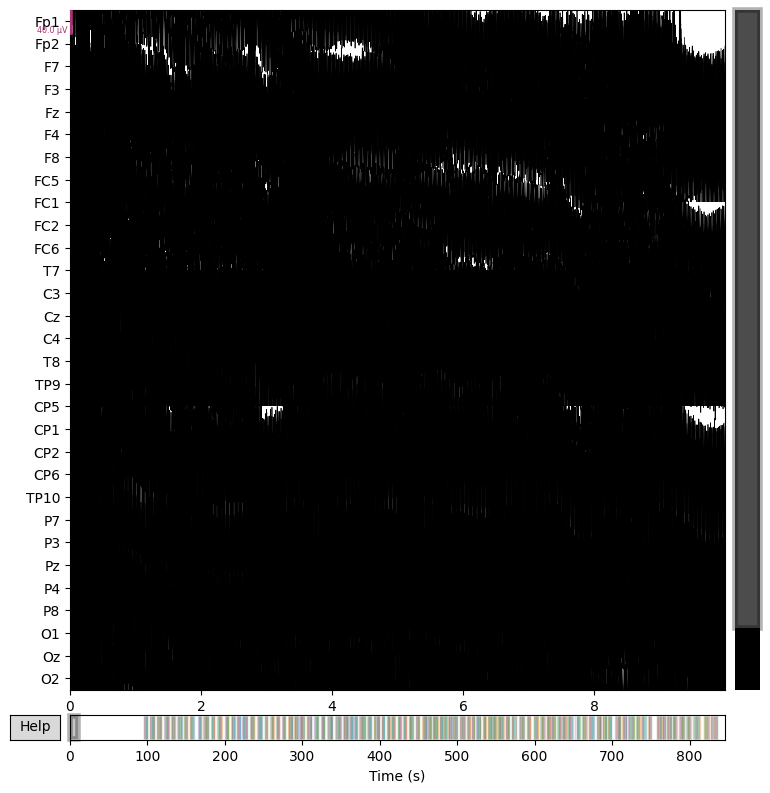

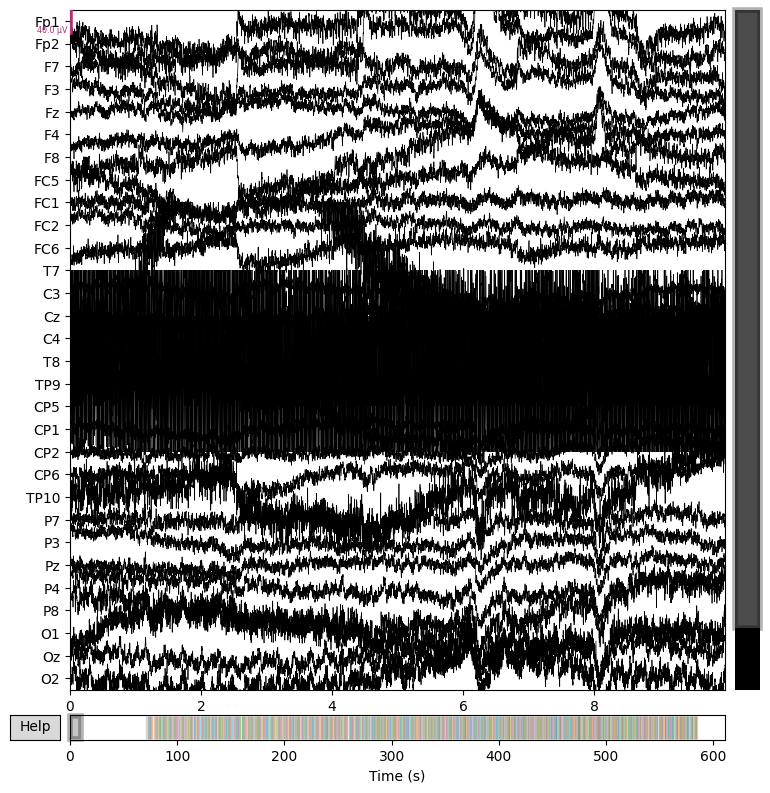

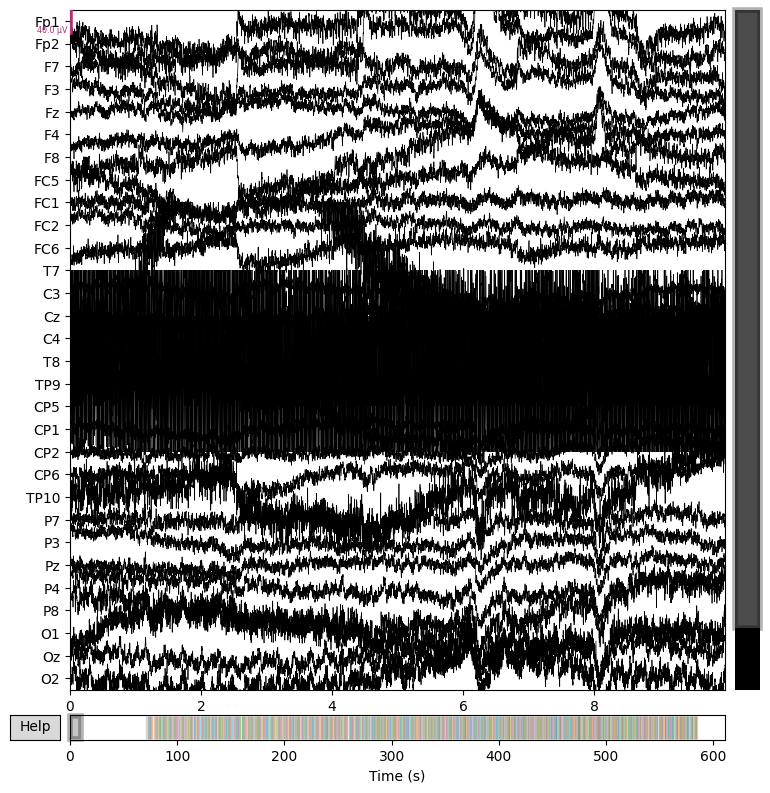

In [3]:
### REFERENCE ###

# Set reference as average
raw_1.set_eeg_reference('average', projection=False, verbose=False)
raw_2.set_eeg_reference('average', projection=False, verbose=False)

# Apply reference
raw_1.apply_proj()
raw_2.apply_proj()

# PLOTTING
raw_1.plot(n_channels=30, scalings=scaling)
raw_2.plot(n_channels=30, scalings=scaling)

In [4]:
### Pick channels ###
raw_1 = raw_1.pick(['eeg', 'eog', 'stim'])
raw_2 = raw_2.pick(['eeg', 'eog', 'stim'])

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 3

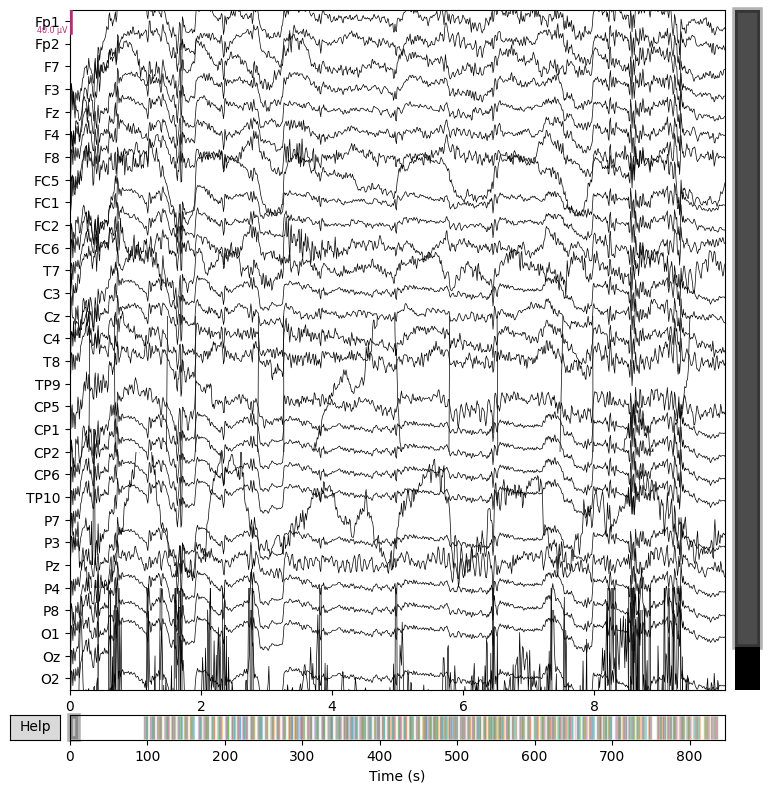

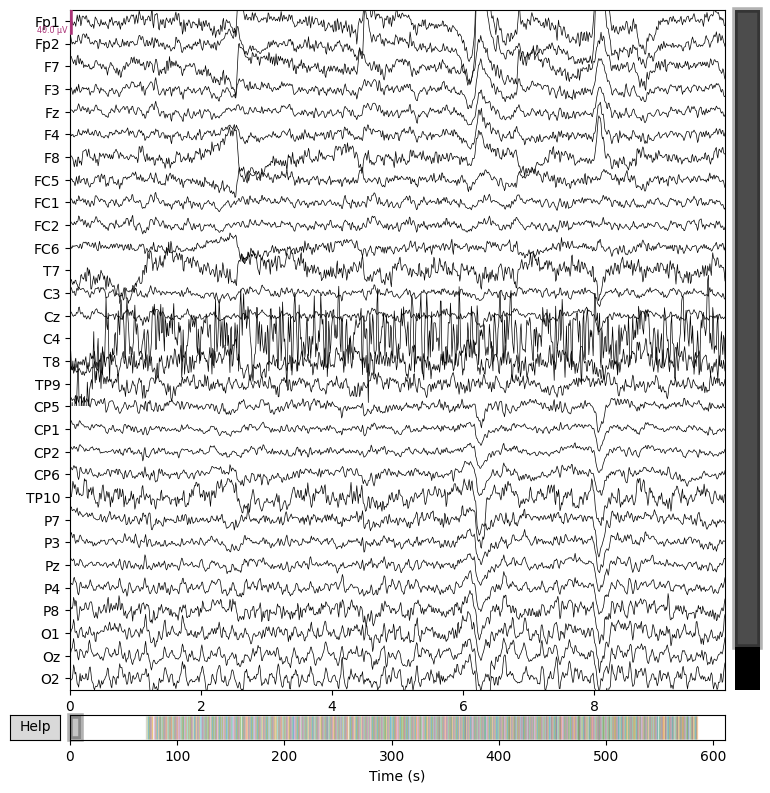

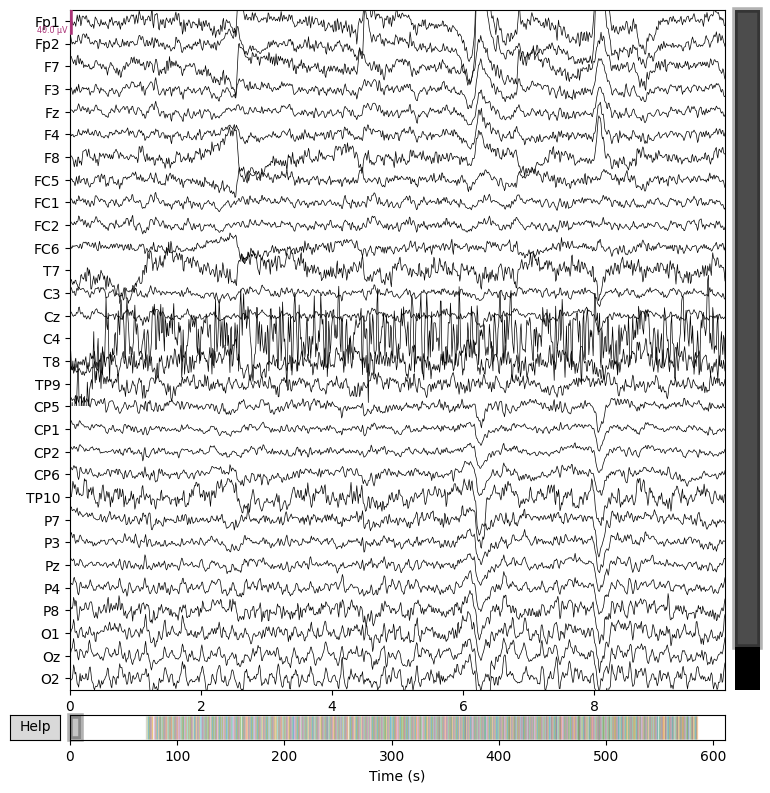

In [5]:
### FILTER ###

# Filter
raw_1.filter(1., 30.)
raw_2.filter(1., 30.)

# Notch filter
raw_1.notch_filter(freqs=50)
raw_2.notch_filter(freqs=50)

# PLOTTING
raw_1.plot(n_channels=30, scalings=scaling)
raw_2.plot(n_channels=30, scalings=scaling)

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.2 mm
Computing interpolation matrix from 29 sensor positions
Interpolating 1 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.2 mm
Computing interpolation matrix from 29 sensor positions
Interpolating 1 sensors


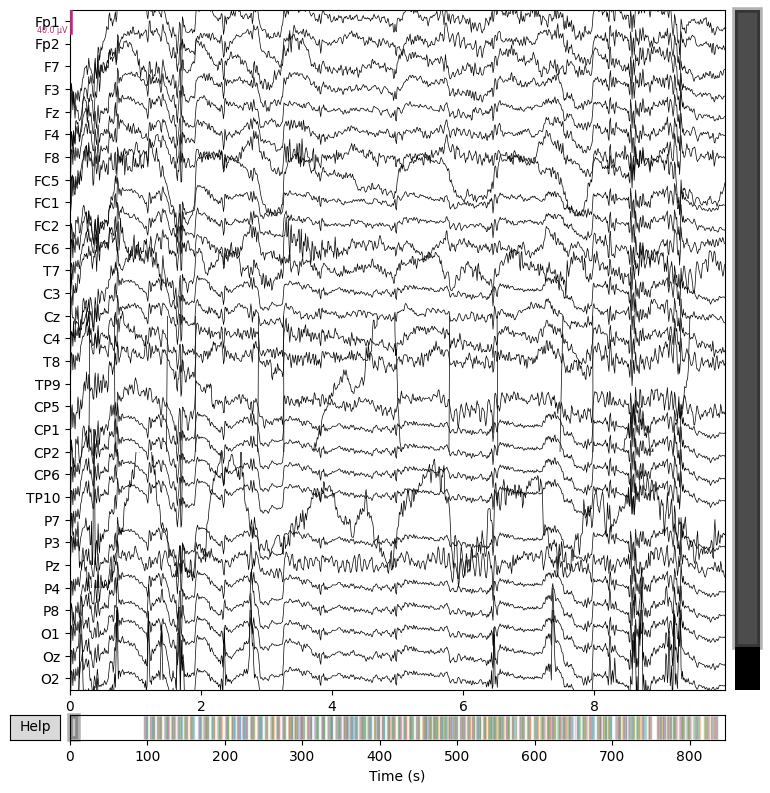

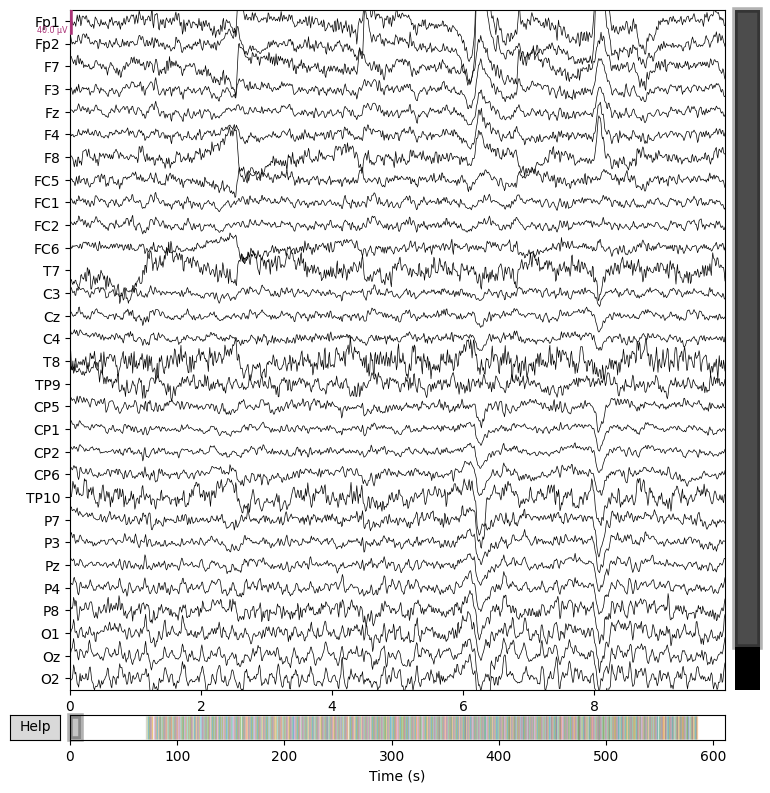

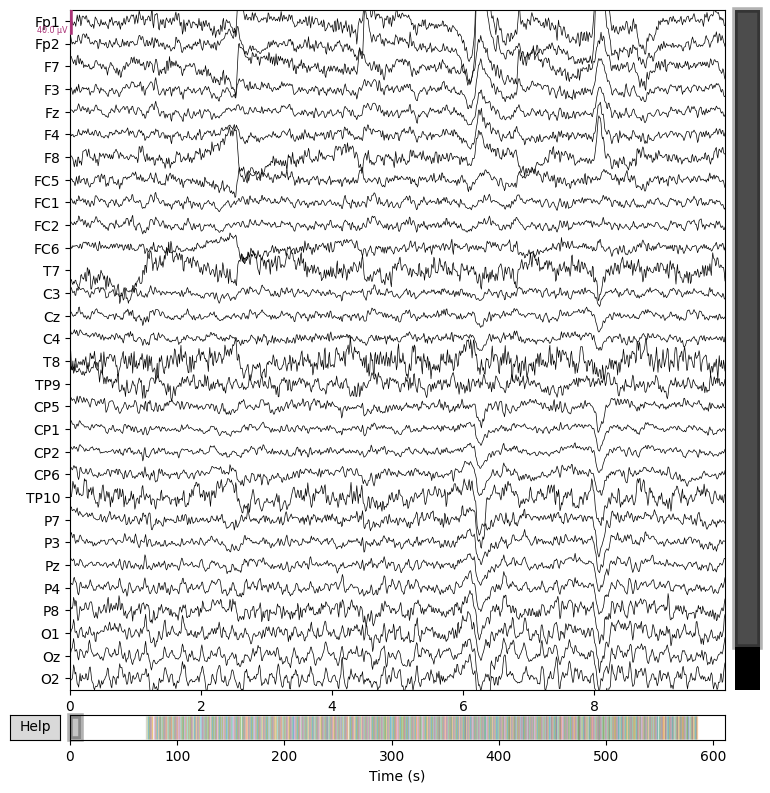

In [6]:
### BAD CHANNELS ###

raw_1.info.ch_names
raw_1.info["bads"] = ["Oz"] #insert channels here as a list of strings seperated by commas e.g. ["channelname1", "channelname20"]  
raw_1.interpolate_bads()
raw_1.pick(['eeg', 'stim', 'eog'], exclude='bads')

raw_2.info.ch_names
raw_2.info["bads"] = ["C4"] #insert channels here as a list of strings seperated by commas e.g. ["channelname1", "channelname20"]  
raw_2.interpolate_bads()
raw_2.pick(['eeg', 'stim', 'eog'], exclude='bads')

# PLOTTING
raw_1.plot(n_channels=30, scalings=scaling)
raw_2.plot(n_channels=30, scalings=scaling)

Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 11.9s.
Using EOG channels: HEOG, VEOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.

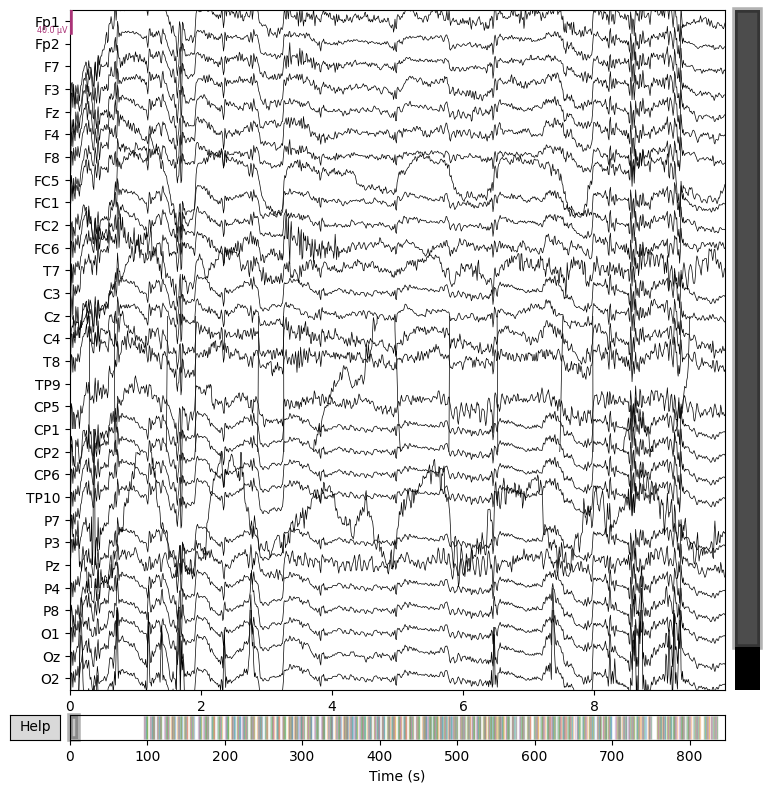

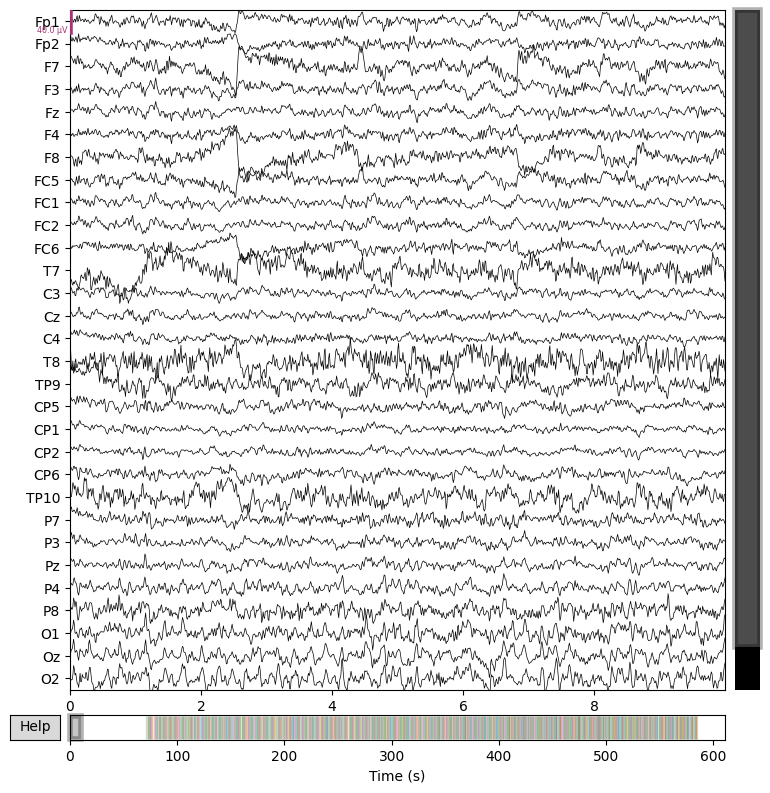

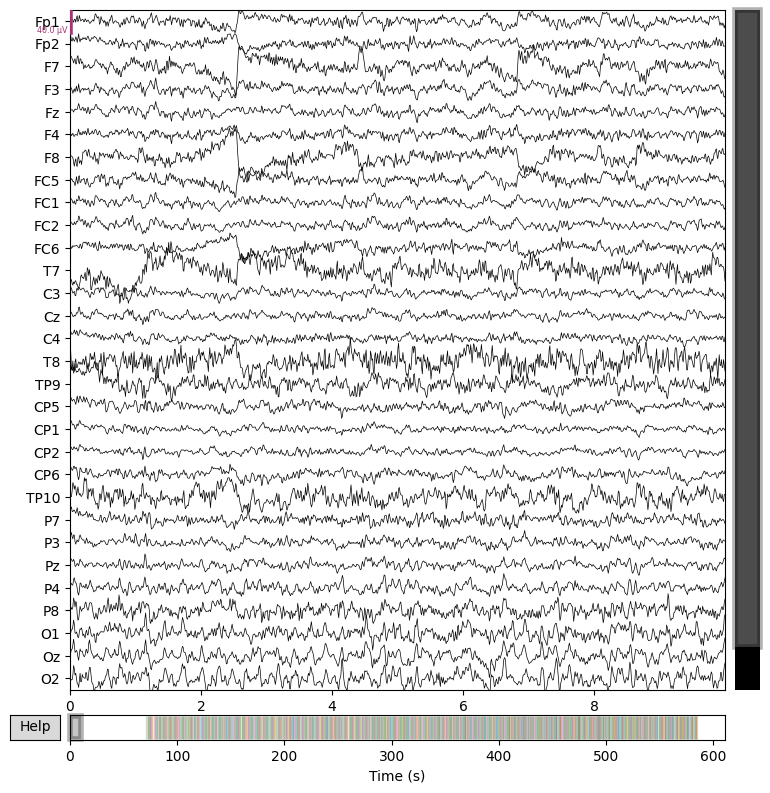

In [7]:
### ICA ###

ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter='auto')
ica.fit(raw_1)
eog_indices, eog_scores = ica.find_bads_eog(raw_1)
ica.exclude = eog_indices
raw_1 = ica.apply(raw_1)


ica_2 = mne.preprocessing.ICA(n_components=0.95, random_state=97)
ica_2.fit(raw_2)
eog_indices_2, _ = ica_2.find_bads_eog(raw_2)
ica_2.exclude = eog_indices_2
raw_2 = ica_2.apply(raw_2)

# PLOTTING
raw_1.plot(n_channels=30, scalings=scaling)
raw_2.plot(n_channels=30, scalings=scaling)


In [8]:
### SAVE ###

import os

output_path = os.path.join(os.getcwd(), "preprocessed_data")

# make sure output path exists 
if not os.path.exists(output_path):
    os.mkdir(output_path)


# save the data
raw_1.save(os.path.join(output_path, 'preprocessed_own_data_1_raw.fif'), overwrite=True)
raw_2.save(os.path.join(output_path, 'preprocessed_own_data_2_raw.fif'), overwrite=True)

Overwriting existing file.
Writing /work/NoraMilenaModla#0145/CogNeuro2025/EEG_LAB/preprocessed_data/preprocessed_own_data_1_raw.fif
Overwriting existing file.
Closing /work/NoraMilenaModla#0145/CogNeuro2025/EEG_LAB/preprocessed_data/preprocessed_own_data_1_raw.fif
[done]
Overwriting existing file.
Writing /work/NoraMilenaModla#0145/CogNeuro2025/EEG_LAB/preprocessed_data/preprocessed_own_data_2_raw.fif
Overwriting existing file.
Closing /work/NoraMilenaModla#0145/CogNeuro2025/EEG_LAB/preprocessed_data/preprocessed_own_data_2_raw.fif
[done]


[PosixPath('/work/NoraMilenaModla#0145/CogNeuro2025/EEG_LAB/preprocessed_data/preprocessed_own_data_2_raw.fif')]

In [9]:
event_id = {
    "Congruent_last": 1,
    "Related_last": 2,
    "Unrelated_last": 3,
    "Congruent_1st": 101,
    "Congruent_2nd": 102,
    "Congruent_3rd": 103,
    "Congruent_4th": 104,
    "Congruent_5th": 105,
    "Congruent_6th": 106,
    "Congruent_7th": 107,
    "Congruent_8th": 108,
    "Congruent_9th": 109,
    "Congruent_10th": 110,
    "Congruent_11th": 111,
    "Congruent_12th": 112,
    "Congruent_13th": 113,
    "Congruent_14th": 114,
    "Related_1st": 201,
    "Related_2nd": 202,
    "Related_3rd": 203,
    "Related_4th": 204,
    "Related_5th": 205,
    "Related_6th": 206,
    "Related_7th": 207,
    "Related_8th": 208,
    "Related_9th": 209,
    "Related_10th": 210,
    "Related_11th": 211,
    "Related_12th": 212,
    "Related_13th": 213,
    "Related_14th": 214,
    "Related_15th": 215,
    "Unrelated_1st": 45,
    "Unrelated_2nd": 46,
    "Unrelated_3rd": 47,
    "Unrelated_4th": 48,
    "Unrelated_5th": 49,
    "Unrelated_6th": 50,
    "Unrelated_7th": 51,
    "Unrelated_8th": 52,
    "Unrelated_9th": 53,
    "Unrelated_10th": 54,
    "Unrelated_11th": 55,
    "Unrelated_12th": 56,
    "Unrelated_13th": 57,
    "Unrelated_14th": 58,
    "Unrelated_15th": 59,
    "Unrelated_16th": 60
}


In [10]:
tmin, tmax = -0.2, 0.8
reject = {'eeg': 150e-6}
picks = ['eeg']

In [11]:
# events separately
events_1, _ = mne.events_from_annotations(raw_1)
events_2, _ = mne.events_from_annotations(raw_2)

event_id = {
    "Congruent_last": 1,
    "Related_last": 2,
    "Unrelated_last": 3,
}

# epochs
epochs_1 = mne.Epochs(raw=raw_1, events=events_1, event_id=event_id, reject=reject, tmin=tmin, tmax=tmax, baseline=(-0.1, 0), preload=True)
epochs_2 = mne.Epochs(raw=raw_2, events=events_2, event_id=event_id, reject=reject, tmin=tmin, tmax=tmax, baseline=(-0.1, 0), preload=True)

# clean selection
congruent_epochs_1 = epochs_1['Congruent_last']
related_epochs_1 = epochs_1['Related_last']
unrelated_epochs_1 = epochs_1['Unrelated_last']

congruent_epochs_2 = epochs_2['Congruent_last']
related_epochs_2 = epochs_2['Related_last']
unrelated_epochs_2 = epochs_2['Unrelated_last']

Used Annotations descriptions: [np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S 45'), np.str_('Stimulus/S 46'), np.str_('Stimulus/S 47'), np.str_('Stimulus/S 48'), np.str_('Stimulus/S 49'), np.str_('Stimulus/S 50'), np.str_('Stimulus/S 51'), np.str_('Stimulus/S 52'), np.str_('Stimulus/S 53'), np.str_('Stimulus/S 54'), np.str_('Stimulus/S 55'), np.str_('Stimulus/S 56'), np.str_('Stimulus/S 57'), np.str_('Stimulus/S 58'), np.str_('Stimulus/S 59'), np.str_('Stimulus/S 60'), np.str_('Stimulus/S101'), np.str_('Stimulus/S102'), np.str_('Stimulus/S103'), np.str_('Stimulus/S104'), np.str_('Stimulus/S105'), np.str_('Stimulus/S106'), np.str_('Stimulus/S107'), np.str_('Stimulus/S108'), np.str_('Stimulus/S109'), np.str_('Stimulus/S110'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S113'), np.str_('Stimulus/S114'), np.str_('Stimulus/S201'), np.str_('Stimulus/S202'), np.str_('Stimulus/S203'), np.str_('Stimulus/S204'), np.str

/tmp/ipykernel_23667/4076673435.py:1: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events=events_1)


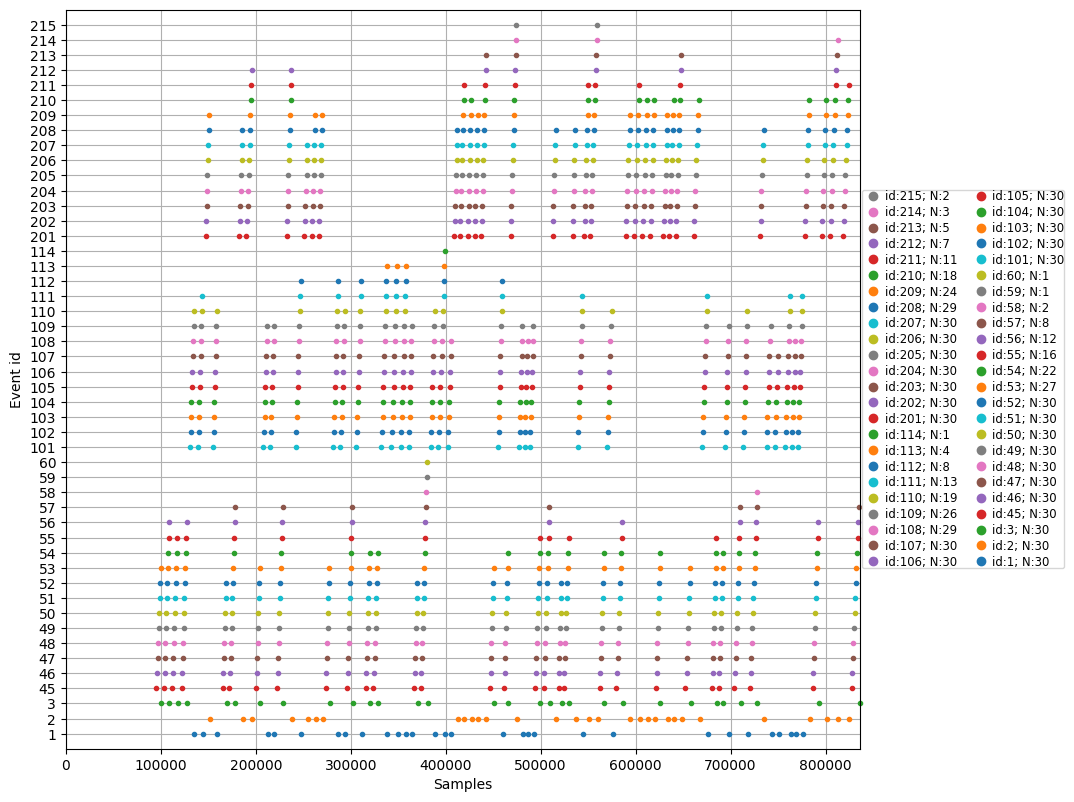

/tmp/ipykernel_23667/4076673435.py:2: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events=events_2)


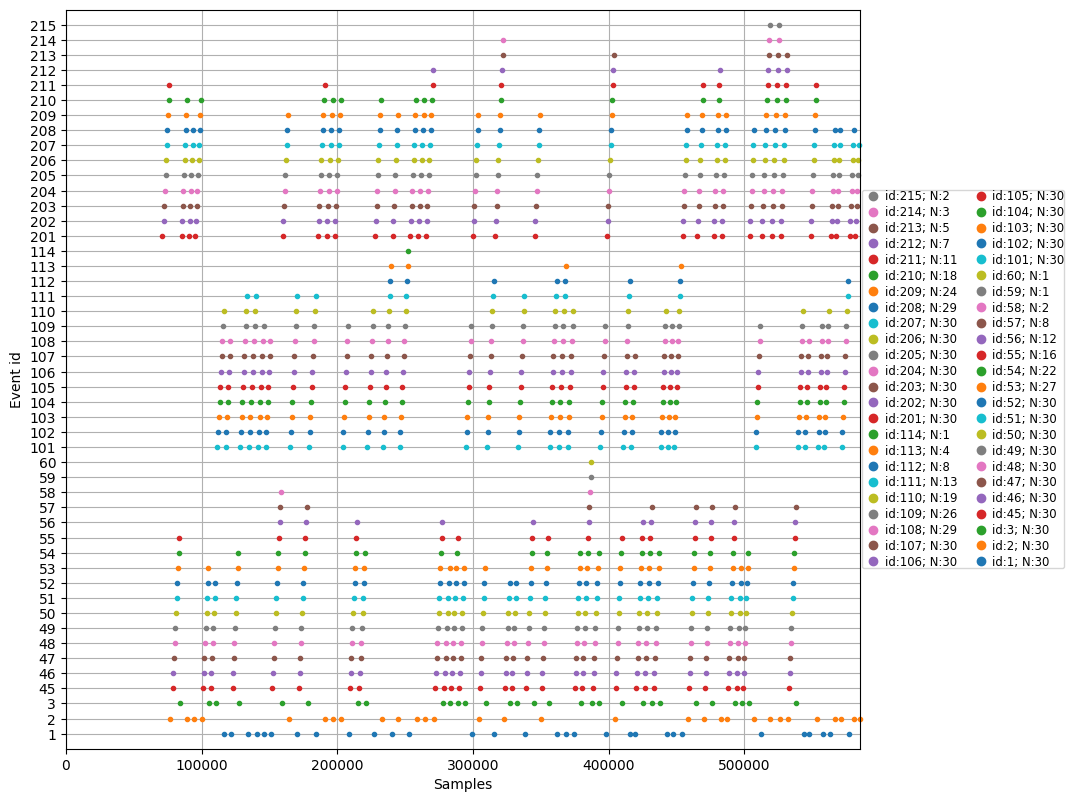

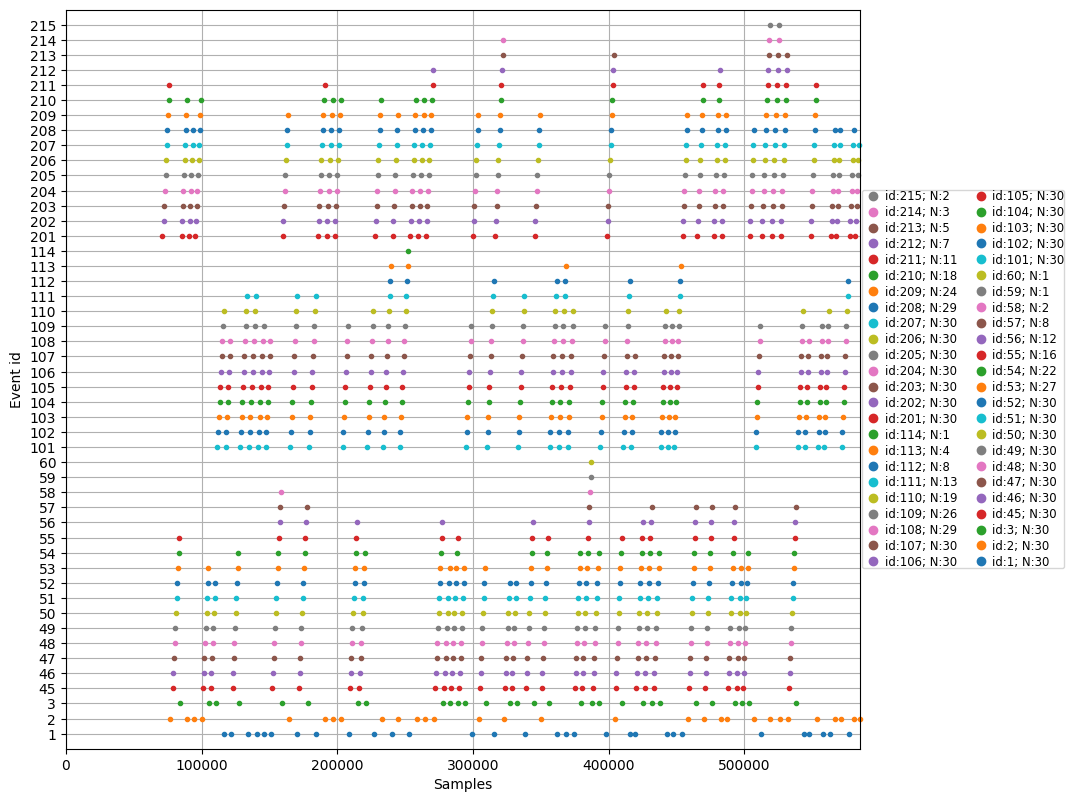

In [12]:
mne.viz.plot_events(events=events_1)
mne.viz.plot_events(events=events_2)

Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated


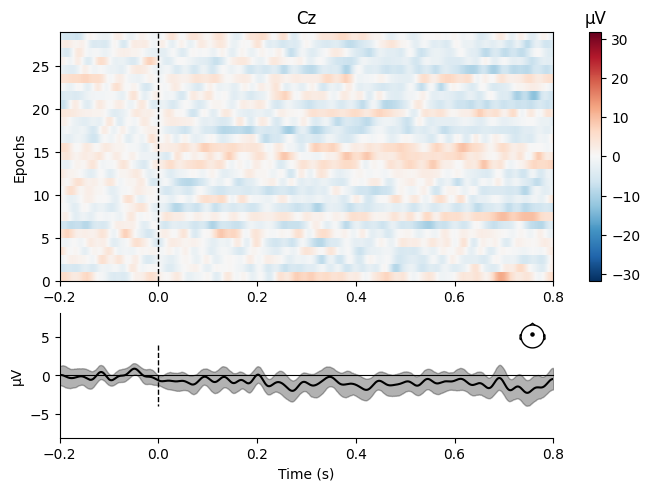

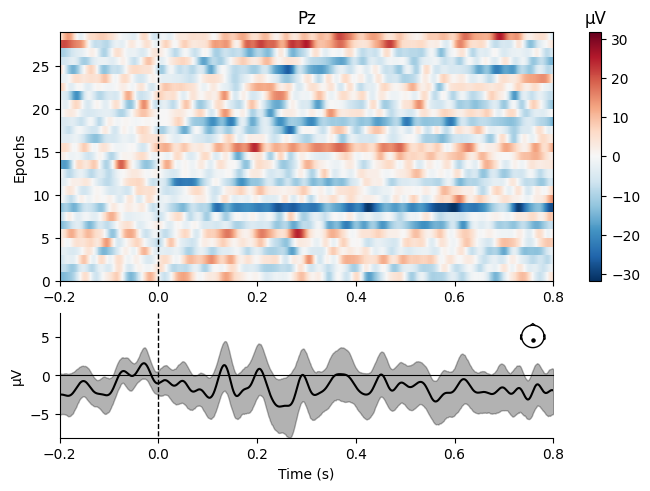

Not setting metadata
25 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
25 matching events found
No baseline correction applied
0 projection items activated


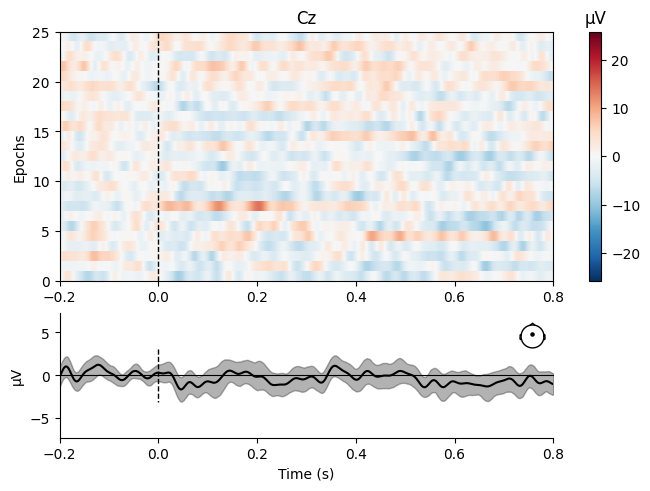

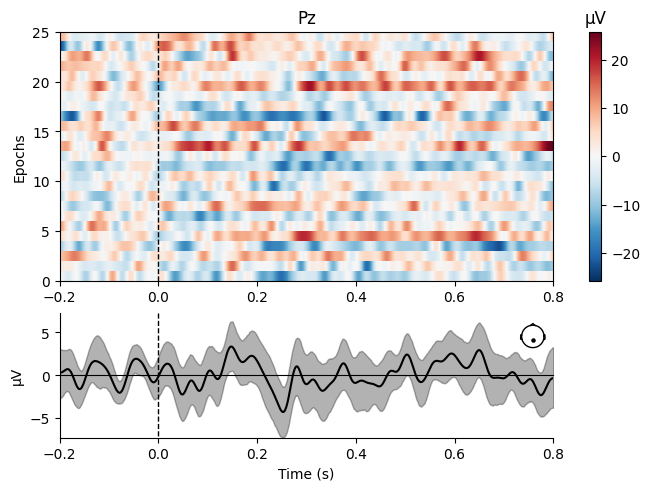

Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated


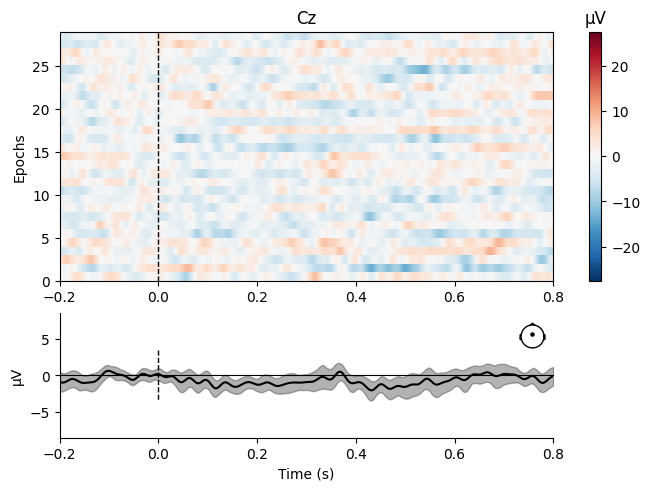

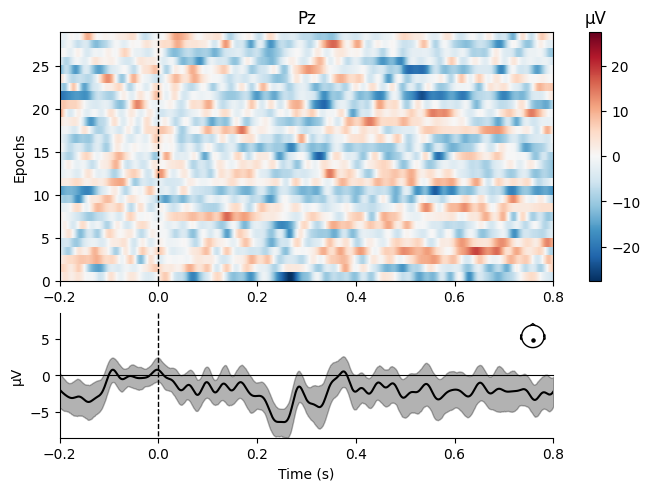

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


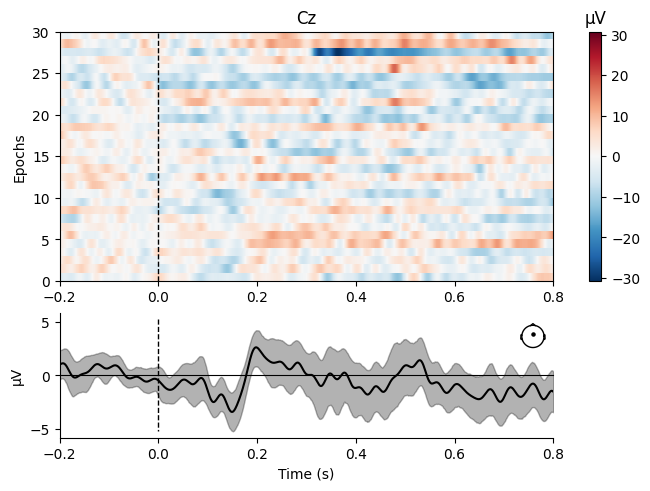

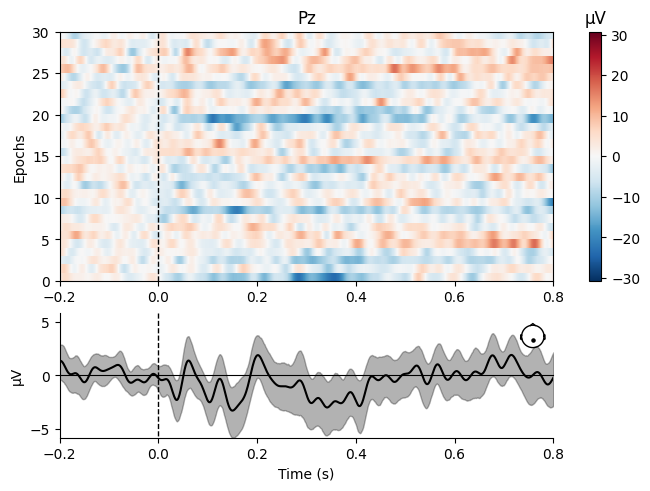

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


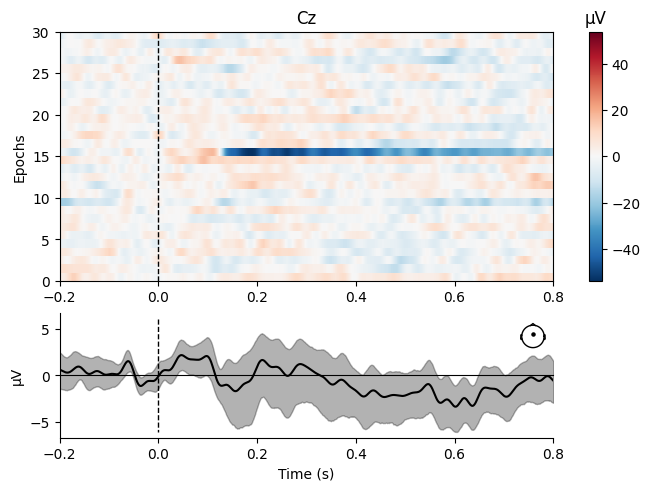

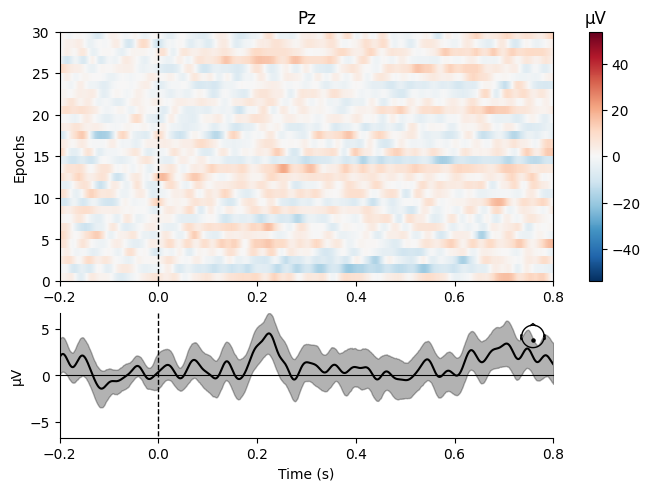

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated


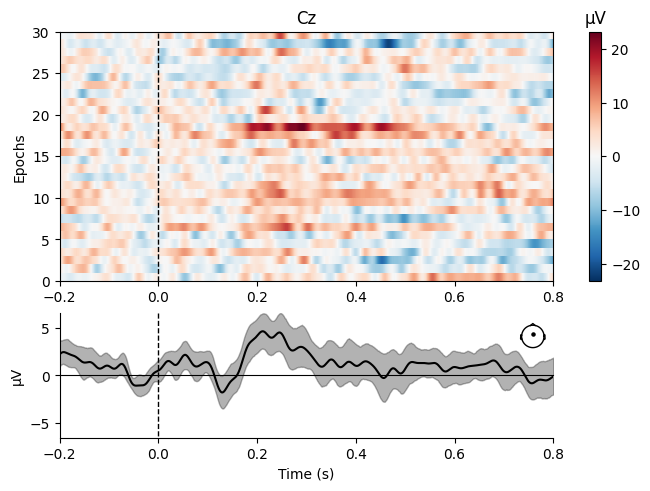

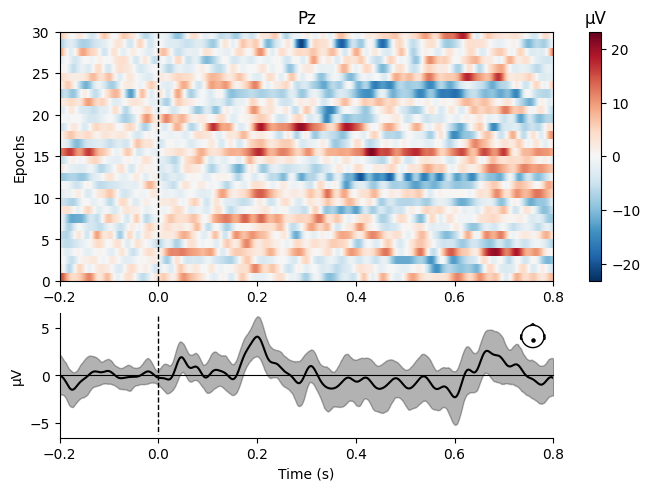

[<Figure size 640x480 with 4 Axes>, <Figure size 640x480 with 4 Axes>]

In [13]:
epochs_1 = epochs_1.resample(sfreq=250)

congruent_epochs_1.plot_image(picks=["Cz", "Pz"])
related_epochs_1.plot_image(picks=["Cz", "Pz"])
unrelated_epochs_1.plot_image(picks=["Cz", "Pz"])

epochs_2.load_data()
epochs_2 = epochs_2.resample(sfreq=250)

congruent_epochs_2.plot_image(picks=["Cz", "Pz"])
related_epochs_2.plot_image(picks=["Cz", "Pz"])
unrelated_epochs_2.plot_image(picks=["Cz", "Pz"])

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


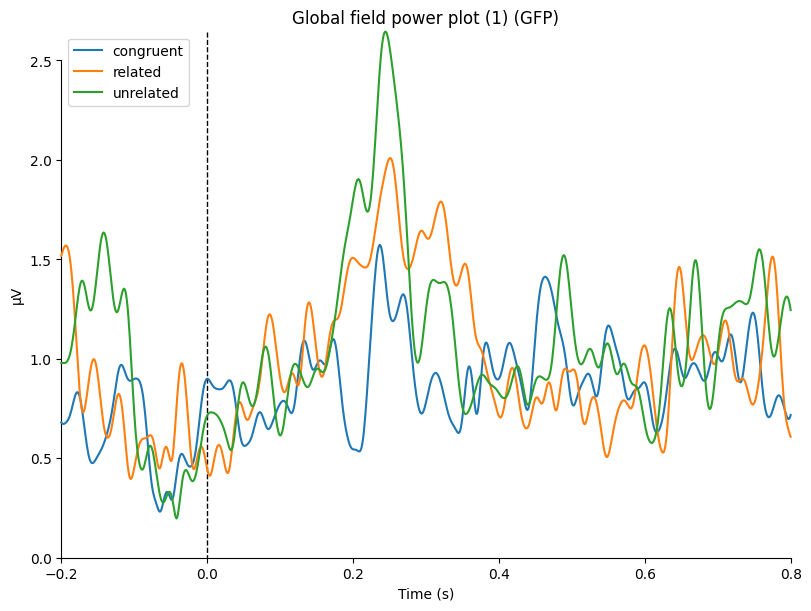

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


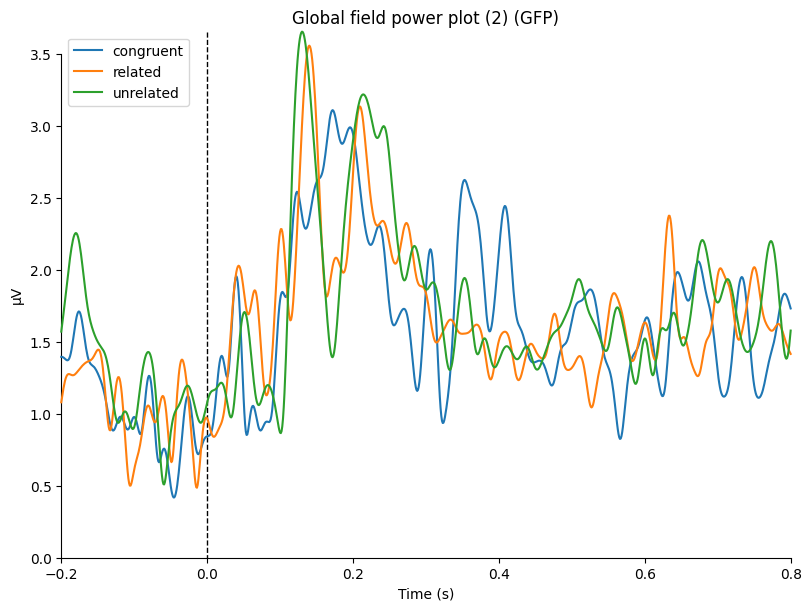

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


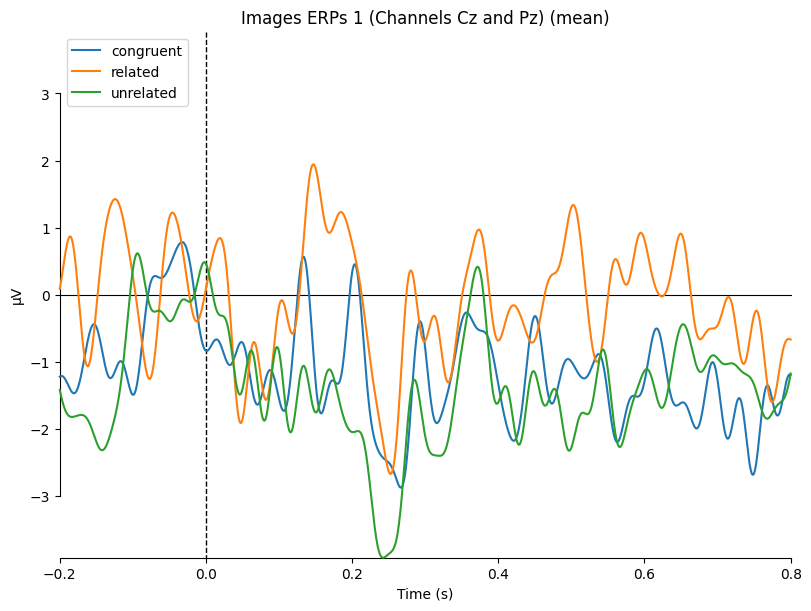

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


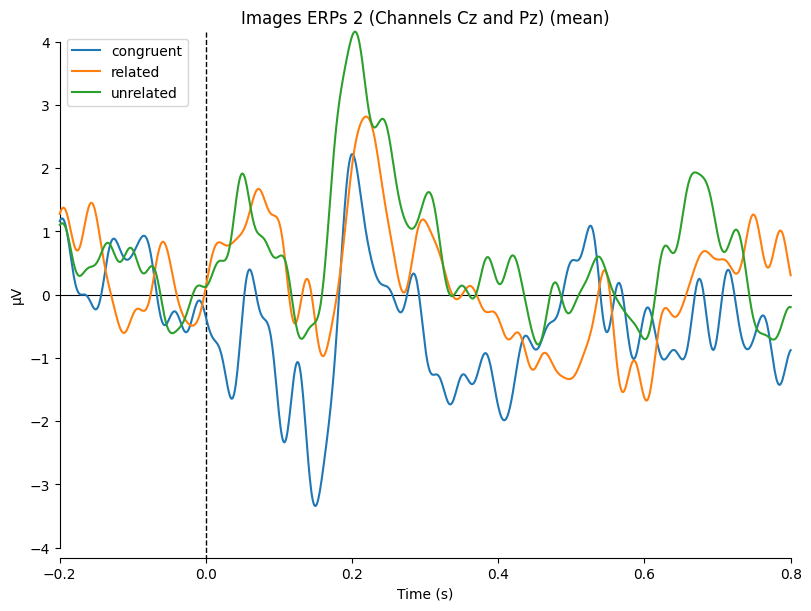

[<Figure size 800x600 with 1 Axes>]

In [14]:
# creating evoked variables

congruent_1 = congruent_epochs_1.average()
related_1 = related_epochs_1.average()
unrelated_1 = unrelated_epochs_1.average()

congruent_2 = congruent_epochs_2.average()
related_2 = related_epochs_2.average()
unrelated_2 = unrelated_epochs_2.average()

# plotting

mne.viz.plot_compare_evokeds(
        {"congruent": congruent_1,
        "related": related_1,
        "unrelated": unrelated_1}, title="Global field power plot (1)", legend='upper left')

mne.viz.plot_compare_evokeds(
        {"congruent": congruent_2,
        "related": related_2,
        "unrelated": unrelated_2}, title="Global field power plot (2)", legend='upper left')


mne.viz.plot_compare_evokeds(
         {"congruent": congruent_1,
        "related": related_1,
        "unrelated": unrelated_1}, picks = ["Pz", "Cz"] , 
        combine="mean", title="Images ERPs 1 (Channels Cz and Pz)", legend='upper left')

mne.viz.plot_compare_evokeds(
         {"congruent": congruent_2,
        "related": related_2,
        "unrelated": unrelated_2}, picks = ["Pz", "Cz"] , 
        combine="mean", title="Images ERPs 2 (Channels Cz and Pz)", legend='upper left')

In [15]:
# chosen channels
picks = ["Fz", "Cz", "Pz"]

# time window for windowed mean in seconds 
tmin = 0.3
tmax = 0.5

# extract the data
data_c1 = congruent_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_r1= related_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_u1 = unrelated_epochs_1.get_data(picks = picks, tmin = tmin, tmax = tmax)

data_c2 = congruent_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_r2= related_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)
data_u2 = unrelated_epochs_2.get_data(picks = picks, tmin = tmin, tmax = tmax)

# averaging over the time window and channels
data_c1_mean = np.mean(data_c1, axis=(1,2))
data_r1_mean = np.mean(data_r1, axis=(1,2))
data_u1_mean = np.mean(data_u1, axis=(1,2))

data_c2_mean = np.mean(data_c2, axis=(1,2))
data_r2_mean = np.mean(data_r2, axis=(1,2))
data_u2_mean = np.mean(data_u2, axis=(1,2))

print(data_c1_mean.shape)
print(data_r1_mean.shape)
print(data_u1_mean.shape)
print(data_c2_mean.shape)
print(data_r2_mean.shape)
print(data_u2_mean.shape)

(29,)
(25,)
(29,)
(30,)
(30,)
(30,)


In [16]:
from scipy import stats

stat_c1, p_c1 = stats.shapiro(data_c1_mean)
stat_r1, p_r1 = stats.shapiro(data_r1_mean)
stat_u1, p_u1 = stats.shapiro(data_u1_mean)

stat_c2, p_c2 = stats.shapiro(data_c2_mean)
stat_r2, p_r2 = stats.shapiro(data_r2_mean)
stat_u2, p_u2 = stats.shapiro(data_u2_mean)

print(f'Congruent 1: statistic={stat_c1:.3f}, p={p_c1:.3f}')
print(f'Related 1: statistic={stat_r1:.3f}, p = {p_r1:.3f}')
print(f'Unrelated 1: statistic={stat_u1:.3f}, p = {p_u1:.3f}')

print(f'Congruent 2: statistic={stat_c2:.3f}, p={p_c2:.3f}')
print(f'Related 2: statistic={stat_r2:.3f}, p = {p_r2:.3f}')
print(f'Unrelated 2: statistic={stat_u2:.3f}, p = {p_u2:.3f}')

Congruent 1: statistic=0.985, p=0.938
Related 1: statistic=0.956, p = 0.342
Unrelated 1: statistic=0.967, p = 0.490
Congruent 2: statistic=0.972, p=0.604
Related 2: statistic=0.951, p = 0.175
Unrelated 2: statistic=0.976, p = 0.722


In [17]:
levene_stat_1, p_levene_1 = stats.levene(data_c1_mean, data_r1_mean, data_u1_mean)

levene_stat_2, p_levene_2 = stats.levene(data_c2_mean, data_r2_mean, data_u2_mean)


print(f"Participant 1: statistic={levene_stat_1:.3f}, {p_levene_1:.3f}")
print(f"Participant 2: statistic={levene_stat_2:.3f}, {p_levene_2:.3f}")

Participant 1: statistic=1.495, 0.230
Participant 2: statistic=0.447, 0.641


In [18]:
F_1, p_1 = stats.f_oneway(data_c1_mean, data_r1_mean, data_u1_mean)

F_2, p_2 = stats.f_oneway(data_c2_mean, data_r2_mean, data_u2_mean)

print(f'Participant 1: F={F_1:.3f}, p={p_1:.3f}')
print(f'Participant 2: F={F_2:.3f}, p={p_2:.3f}')

Participant 1: F=1.621, p=0.204
Participant 2: F=0.244, p=0.784


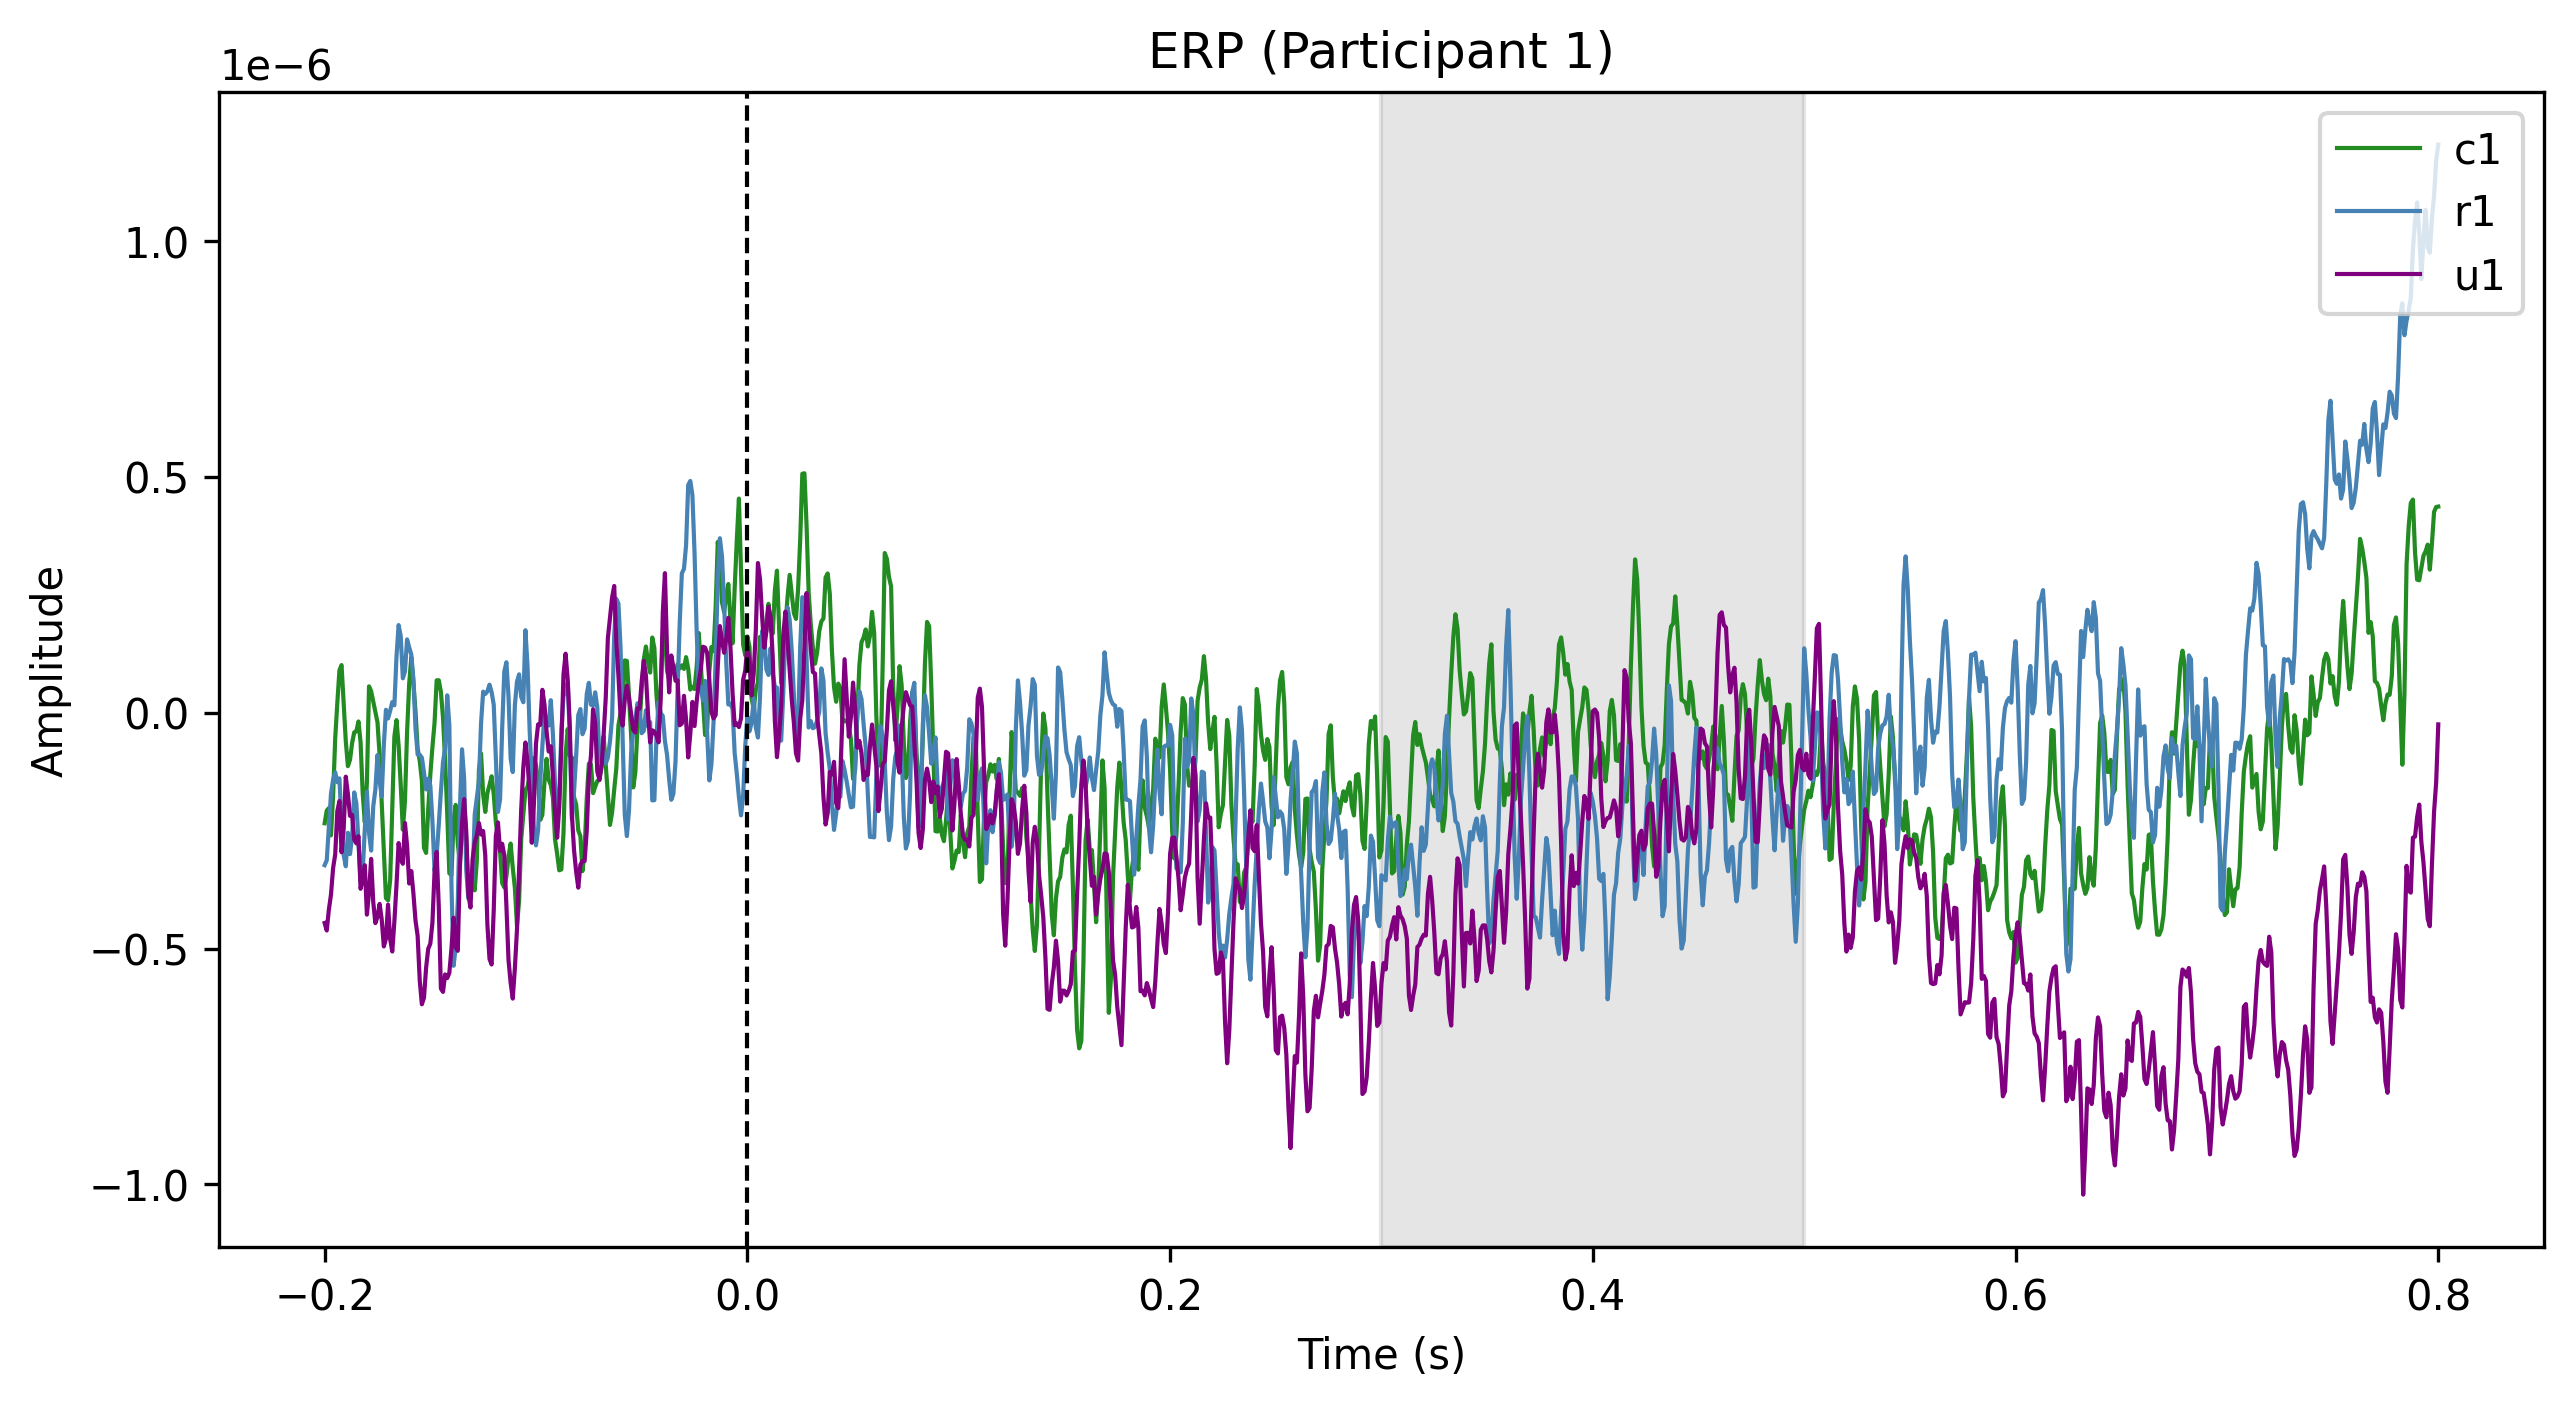

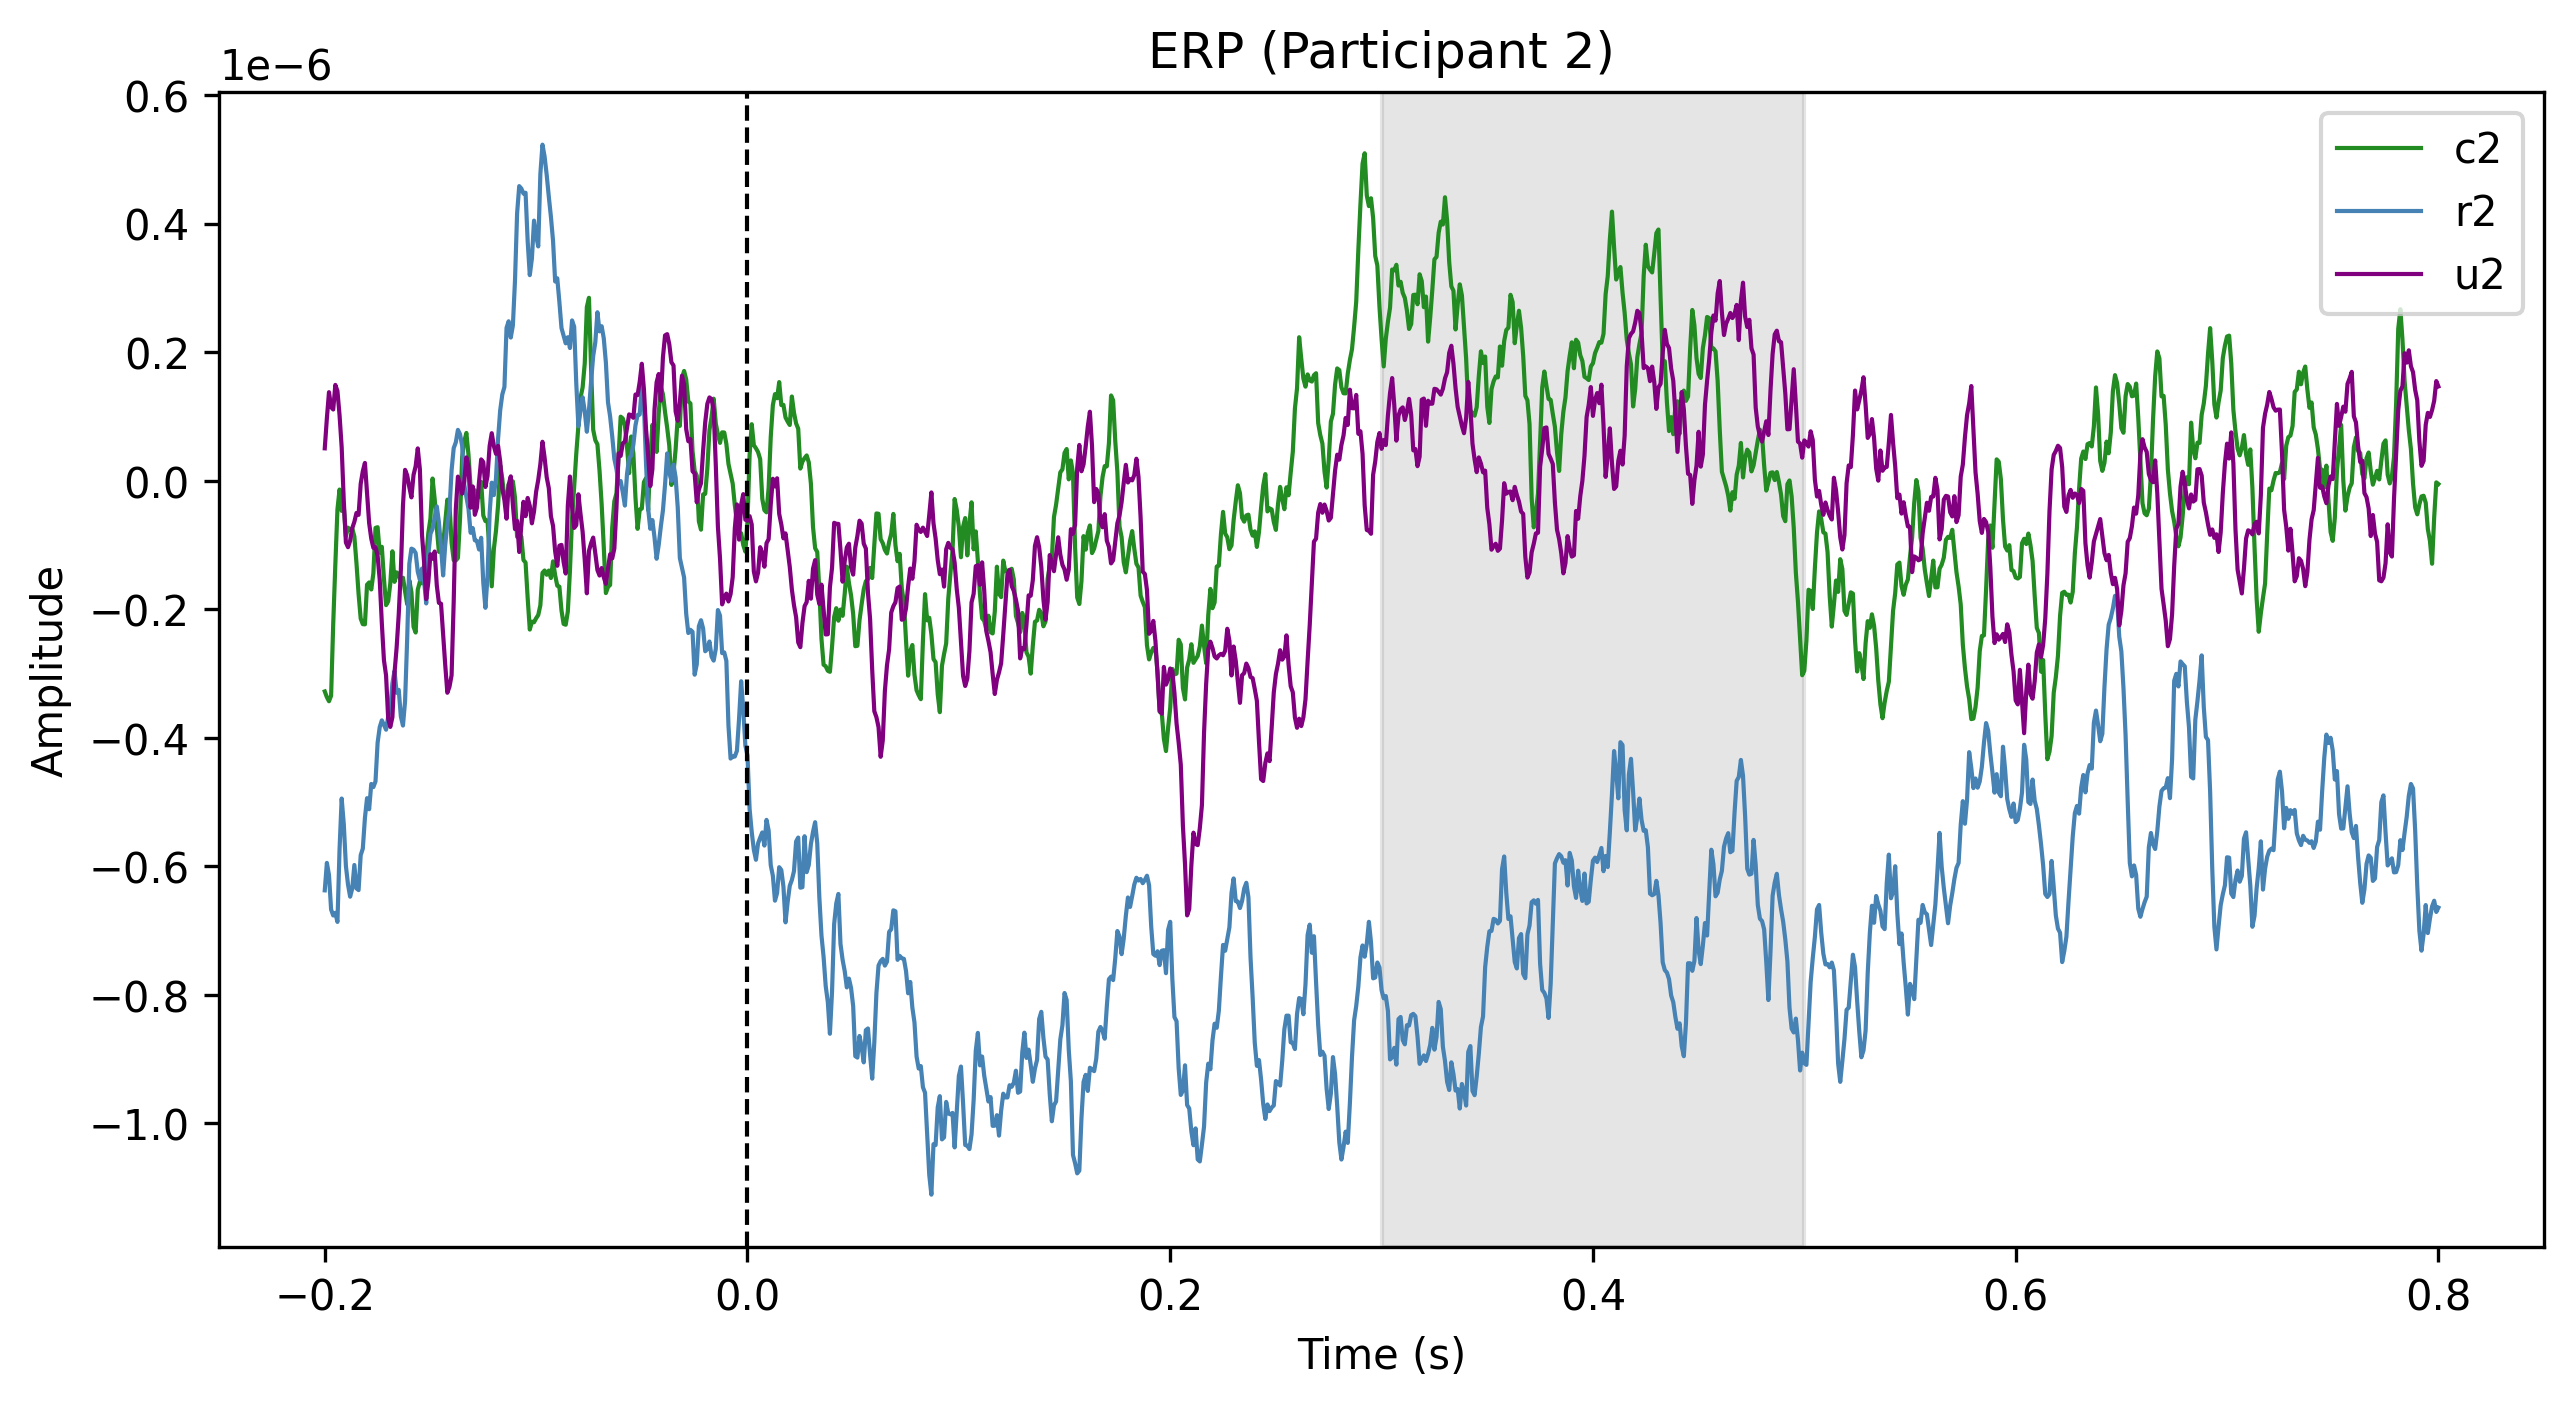

In [19]:
plot_data_c1 = congruent_epochs_1.get_data(copy = True).mean(axis=(0, 1))
plot_data_r1= related_epochs_1.get_data(copy = True).mean(axis=(0, 1))
plot_data_u1 = unrelated_epochs_1.get_data(copy = True).mean(axis=(0, 1))

plot_data_c2 = congruent_epochs_2.get_data(copy = True).mean(axis=(0, 1))
plot_data_r2= related_epochs_2.get_data(copy = True).mean(axis=(0, 1))
plot_data_u2 = unrelated_epochs_2.get_data(copy = True).mean(axis=(0, 1))

times = congruent_epochs_1.times

fig, ax = plt.subplots(1, figsize=(10, 5), dpi=300)

# plot the time window
ax.axvspan(tmin, tmax, color="grey", alpha=0.2)

# plot the time course
ax.plot(times, plot_data_c1.T, label="c1", linewidth=1, color="forestgreen")
ax.plot(times, plot_data_r1.T, label="r1", linewidth=1, color="steelblue")
ax.plot(times, plot_data_u1.T, label="u1", linewidth=1, color="purple")

# vertical line at 0
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

ax.set(xlabel="Time (s)", ylabel="Amplitude", title="ERP (Participant 1)")
ax.legend(loc = "upper right")

fig, ax = plt.subplots(1, figsize=(10, 5), dpi=300)

# plot the time window
ax.axvspan(tmin, tmax, color="grey", alpha=0.2)

# plot the time course
ax.plot(times, plot_data_c2.T, label="c2", linewidth=1, color="forestgreen")
ax.plot(times, plot_data_r2.T, label="r2", linewidth=1, color="steelblue")
ax.plot(times, plot_data_u2.T, label="u2", linewidth=1, color="purple")

# vertical line at 0
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

ax.set(xlabel="Time (s)", ylabel="Amplitude", title="ERP (Participant 2)")
ax.legend(loc = "upper right")